# Notebook 06 - Regression and Index Comparison

This notebook compares the CRI against two well-established external indices:
- **ITU Global Cybersecurity Index (GCI) 2024** - the closest existing index to the CRI
- **UN Human Development Index (HDI)** - a general development measure

**Steps:**
1. Pearson correlation between CRI and each external index
2. Scatter plots showing the relationships
3. Multiple Linear Regression (MLR) with CRI as the dependent variable and GCI score, HDI score, and GDP per capita as independent variables
4. Interpretation of R-squared, p-values, and coefficients

In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from scipy.stats import pearsonr
from IPython.display import display

PROCESSED = '../data/processed/'

df = pd.read_csv(f'{PROCESSED}cri_scores.csv')
print(f'Loaded shape: {df.shape}')
print(f'Columns: {df.columns.tolist()}')
display(df.head())

Loaded shape: (35, 10)
Columns: ['country', 'technical_capacity', 'legal_regulatory', 'capacity_building', 'organisational_measures', 'cri_score', 'cri_rank', 'gci_overall', 'hdi_score', 'gdp_per_capita']


,country,technical_capacity,legal_regulatory,capacity_building,organisational_measures,cri_score,cri_rank,gci_overall,hdi_score,gdp_per_capita
0,United Kingdom,0.944173,1.0,1.000000,1.000000,0.986043,1,99.54,0.940,49944.470212
1,Spain,0.937356,1.0,0.992307,0.974052,0.975929,2,98.52,0.911,33493.222541
2,Estonia,0.852825,1.0,0.976968,1.000000,0.957448,3,99.48,0.899,30264.006489
3,Germany,0.887191,1.0,0.982378,0.959229,0.957200,4,97.41,0.950,54776.766824
4,Portugal,0.906974,1.0,0.946626,0.974052,0.956913,5,97.32,0.874,27634.618314


## 1. Check Available Benchmark Columns

In [16]:
# Confirm which benchmark columns are present
for col in ['gci_overall', 'hdi_score', 'gdp_per_capita']:
    if col in df.columns:
        n_missing = df[col].isnull().sum()
        print(f'{col}: present, {n_missing} missing values')
    else:
        print(f'{col}: NOT FOUND - check notebook 05')

# Drop rows where any regression variable is missing
regression_cols = ['cri_score', 'gci_overall', 'hdi_score', 'gdp_per_capita']
available_cols = [c for c in regression_cols if c in df.columns]
df_reg = df[['country'] + available_cols].dropna().reset_index(drop=True)
print(f'\nRows available for regression: {len(df_reg)}')

gci_overall: present, 0 missing values
hdi_score: present, 0 missing values
gdp_per_capita: present, 0 missing values

Rows available for regression: 35


## 2. Pearson Correlation

Pearson correlation measures the linear relationship between two variables. A high positive correlation with GCI would validate that the CRI is measuring something similar. A high correlation with HDI would suggest the CRI partly reflects general development level rather than cybersecurity-specific factors.

In [17]:
print('Pearson Correlations with CRI Score:')
print(f'{"Variable":<25} {"r":>8} {"p-value":>12}')
print('-' * 48)

for col in ['gci_overall', 'hdi_score', 'gdp_per_capita']:
    if col in df_reg.columns:
        r, p = pearsonr(df_reg['cri_score'], df_reg[col])
        sig = '***' if p < 0.001 else '**' if p < 0.01 else '*' if p < 0.05 else ''
        print(f'{col:<25} {r:>8.4f} {p:>12.4f} {sig}')

print('\nSignificance: * p<0.05  ** p<0.01  *** p<0.001')

Pearson Correlations with CRI Score:
Variable                         r      p-value
------------------------------------------------
gci_overall                 0.9607       0.0000 ***
hdi_score                   0.4287       0.0102 *
gdp_per_capita              0.4060       0.0155 *

Significance: * p<0.05  ** p<0.01  *** p<0.001


## 3. Scatter Plots - CRI vs External Indices

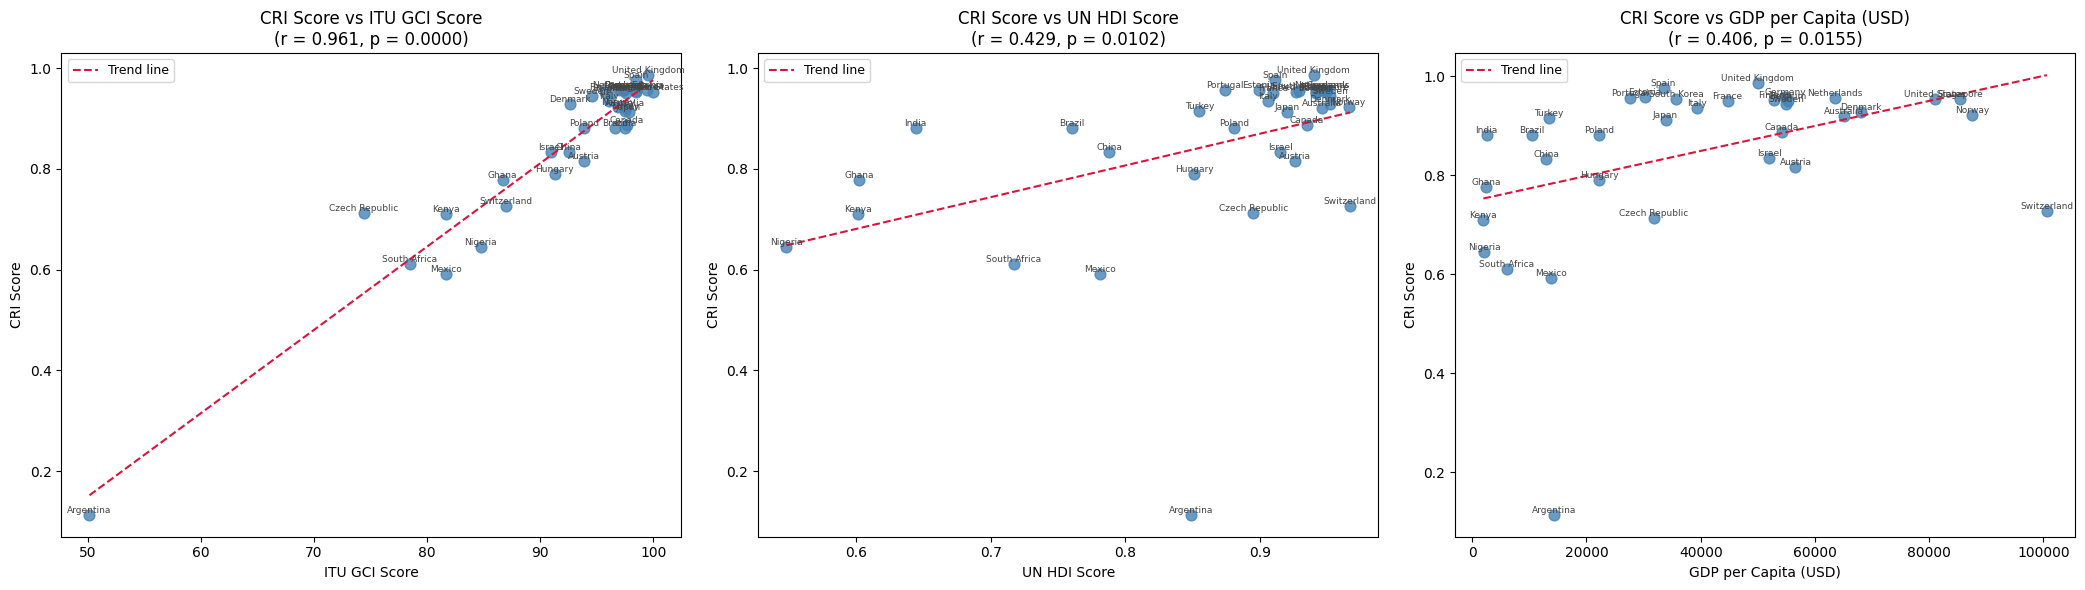

Saved: report/figures/06_scatter_comparisons.png


In [18]:
comparison_pairs = [
    ('gci_overall', 'ITU GCI Score'),
    ('hdi_score',   'UN HDI Score'),
    ('gdp_per_capita', 'GDP per Capita (USD)'),
]
available_pairs = [(col, label) for col, label in comparison_pairs if col in df_reg.columns]

fig, axes = plt.subplots(1, len(available_pairs), figsize=(7 * len(available_pairs), 6))
if len(available_pairs) == 1:
    axes = [axes]

for ax, (col, label) in zip(axes, available_pairs):
    ax.scatter(df_reg[col], df_reg['cri_score'], color='steelblue', s=60, alpha=0.8)
    for _, row in df_reg.iterrows():
        ax.annotate(row['country'], (row[col], row['cri_score']),
                    fontsize=6.5, ha='center', va='bottom', color='#444444')
    m, b = np.polyfit(df_reg[col].dropna(), df_reg['cri_score'].dropna(), 1)
    x_line = np.linspace(df_reg[col].min(), df_reg[col].max(), 100)
    ax.plot(x_line, m * x_line + b, color='crimson', linewidth=1.5, linestyle='--', label='Trend line')
    r, p = pearsonr(df_reg['cri_score'], df_reg[col])
    ax.set_title(f'CRI Score vs {label}\n(r = {r:.3f}, p = {p:.4f})', fontsize=12)
    ax.set_xlabel(label)
    ax.set_ylabel('CRI Score')
    ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig('../report/figures/06_scatter_comparisons.png', dpi=150)
plt.show()
print('Saved: report/figures/06_scatter_comparisons.png')

## 4. Multiple Linear Regression

Multiple Linear Regression (MLR) is used to model the CRI score as a linear combination of the external variables. This tells us how much of the variation in the CRI can be explained by GCI, HDI, and GDP per capita together.

- **R-squared** - proportion of variance in CRI explained by the model
- **Coefficients** - how much the CRI changes for a one-unit increase in each predictor
- **p-values** - whether each predictor has a statistically significant relationship with the CRI

In [19]:
predictor_cols = [c for c in ['gci_overall', 'hdi_score', 'gdp_per_capita'] if c in df_reg.columns]

X = df_reg[predictor_cols].copy()
y = df_reg['cri_score'].copy()

# Standardise GDP per capita (much larger scale than the others)
if 'gdp_per_capita' in X.columns:
    X['gdp_per_capita'] = X['gdp_per_capita'] / X['gdp_per_capita'].max()

X_const = sm.add_constant(X)
model = sm.OLS(y, X_const).fit()

print(model.summary())


                            OLS Regression Results                            
Dep. Variable:              cri_score   R-squared:                       0.931
Model:                            OLS   Adj. R-squared:                  0.925
Method:                 Least Squares   F-statistic:                     140.2
Date:                Sat, 16 May 2026   Prob (F-statistic):           4.10e-18
Time:                        15:41:47   Log-Likelihood:                 60.135
No. Observations:                  35   AIC:                            -112.3
Df Residuals:                      31   BIC:                            -106.0
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                     coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------
const             -0.7704      0.108     -7.

## 5. Regression Coefficient Plot

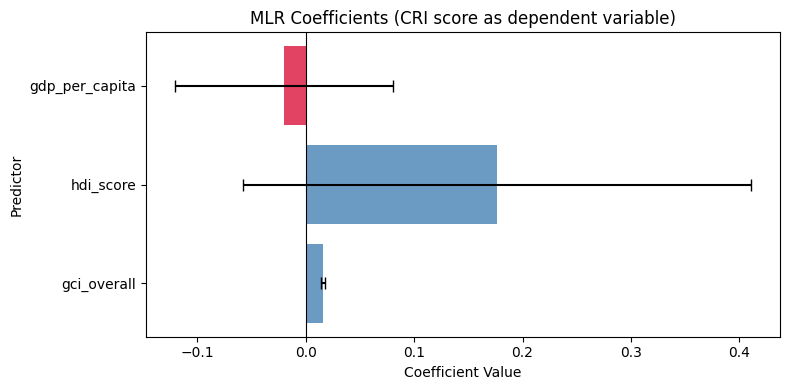

Saved: report/figures/06_regression_coefficients.png


In [20]:
coef = model.params.drop('const')
conf = model.conf_int().drop('const')
errors = [(coef[i] - conf.loc[i, 0], conf.loc[i, 1] - coef[i]) for i in coef.index]
lower_err = [e[0] for e in errors]
upper_err = [e[1] for e in errors]

fig, ax = plt.subplots(figsize=(8, 4))
colors = ['steelblue' if c > 0 else 'crimson' for c in coef.values]
ax.barh(coef.index, coef.values, xerr=[lower_err, upper_err],
        color=colors, alpha=0.8, capsize=4)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_title('MLR Coefficients (CRI score as dependent variable)', fontsize=12)
ax.set_xlabel('Coefficient Value')
ax.set_ylabel('Predictor')
plt.tight_layout()
plt.savefig('../report/figures/06_regression_coefficients.png', dpi=150)
plt.show()
print('Saved: report/figures/06_regression_coefficients.png')

## 6. Interpretation of Results

This section interprets the regression output in the context of validating the CRI.

**Correlation with GCI:** A high Pearson r with the ITU GCI indicates the CRI is measuring a similar underlying construct. Since both indices draw on GCI pillar scores, some correlation is expected. If r > 0.85, the CRI is tracking the same phenomenon but offering a different weighting and sub-index structure.

**Correlation with HDI:** A high r with HDI would suggest the CRI is partly capturing general development rather than cybersecurity readiness specifically. If the CRI-HDI correlation is substantially lower than the CRI-GCI correlation, that is evidence the index is adding cybersecurity-specific signal beyond what general development alone would predict.

**Regression R-squared:** The proportion of CRI variance explained by GCI, HDI, and GDP together. A very high R-squared (e.g. > 0.90) would suggest the CRI is largely derivable from existing indices. A moderate R-squared would suggest the CRI captures something distinct.

**Significant predictors:** Variables with p < 0.05 have a statistically significant independent relationship with the CRI after controlling for the other predictors. If HDI or GDP are significant predictors after controlling for GCI, it would indicate the CRI is partly rewarding general wealth rather than cybersecurity investment specifically -- a known limitation of composite indicators built from publicly available country-level data.

In [21]:
print(f'R-squared:         {model.rsquared:.4f}')
print(f'Adjusted R-squared:{model.rsquared_adj:.4f}')
print(f'F-statistic:       {model.fvalue:.4f}')
print(f'F p-value:         {model.f_pvalue:.4f}')
print()
print('Coefficient p-values:')
for var in predictor_cols:
    p = model.pvalues[var]
    sig = '***' if p < 0.001 else '**' if p < 0.01 else '*' if p < 0.05 else 'not significant'
    print(f'  {var:<25} p = {p:.4f}  ({sig})')

R-squared:         0.9313
Adjusted R-squared:0.9247
F-statistic:       140.1540
F p-value:         0.0000

Coefficient p-values:
  gci_overall               p = 0.0000  (***)
  hdi_score                 p = 0.1349  (not significant)
  gdp_per_capita            p = 0.6853  (not significant)
